In [24]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.pipeline import Pipeline

In [25]:
data = pd.read_parquet("chicago_sales_with_crime.parquet")

In [26]:
features_to_exclude = ["pin","is_multisale", "sale_filter_same_sale_within_365", "sale_filter_less_than_10k", "single_v_multi_family", "zip_code",
                      "longitude", "latitude", "sale_date_parsed", "class", 'centroid_x_crs_3435', 'centroid_y_crs_3435', 
                       "school_elementary_district_name", "school_secondary_district_name", "township_code",  "neighborhood_code"]

In [27]:
features = []
for c in data.columns:
    if c in features_to_exclude:
        continue
    features.append(c)

In [28]:
cat_cols = ["type_of_residence", "construction_quality", "attic_finish", "garage_size",
            "basement_type", "ext_wall_material", "repair_condition", "basement_finish",
            "central_heating", "central_air"]

for col in cat_cols:
    data[col] = data[col].astype("category")

# Drop or engineer PIN columns
data = data.drop(columns=["pin10", "nearest_new_construction_pin10", "nearest_vacant_land_pin10",
                       "nearest_neighbor_1_pin10", "nearest_neighbor_2_pin10", "nearest_neighbor_3_pin10"])

In [29]:
for c in ["pin10", "nearest_new_construction_pin10", "nearest_vacant_land_pin10",
                       "nearest_neighbor_1_pin10", "nearest_neighbor_2_pin10", "nearest_neighbor_3_pin10", "sale_date"]:
    features.remove(c)

In [30]:
y=data["sale_price"]
features.remove("sale_price")
X=data[features]
model = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, enable_categorical=True, tree_method="hist")

# 2. Set up cross-validation splitting strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Run cross-validation with multiple scoring metrics
scoring = {
    "r2": "r2",
    "neg_mae": "neg_mean_absolute_error",
    "neg_rmse": "neg_root_mean_squared_error"
}

results = cross_validate(
    model, X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

# 4. Summarize results
print("R²:    mean = {:.4f}, std = {:.4f}".format(
    results["test_r2"].mean(), results["test_r2"].std()))
print("MAE:   mean = {:.4f}, std = {:.4f}".format(
    -results["test_neg_mae"].mean(), results["test_neg_mae"].std()))
print("RMSE:  mean = {:.4f}, std = {:.4f}".format(
    -results["test_neg_rmse"].mean(), results["test_neg_rmse"].std()))

# Optional: compare to train scores to check for overfitting
print("\nTrain R² (for comparison): {:.4f}".format(results["train_r2"].mean()))

R²:    mean = 0.8669, std = 0.0374
MAE:   mean = 91196.7437, std = 885.7400
RMSE:  mean = 168120.5531, std = 22882.8712

Train R² (for comparison): 0.9281


In [32]:
 model.fit(X,y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [36]:
import matplotlib.pyplot as plt

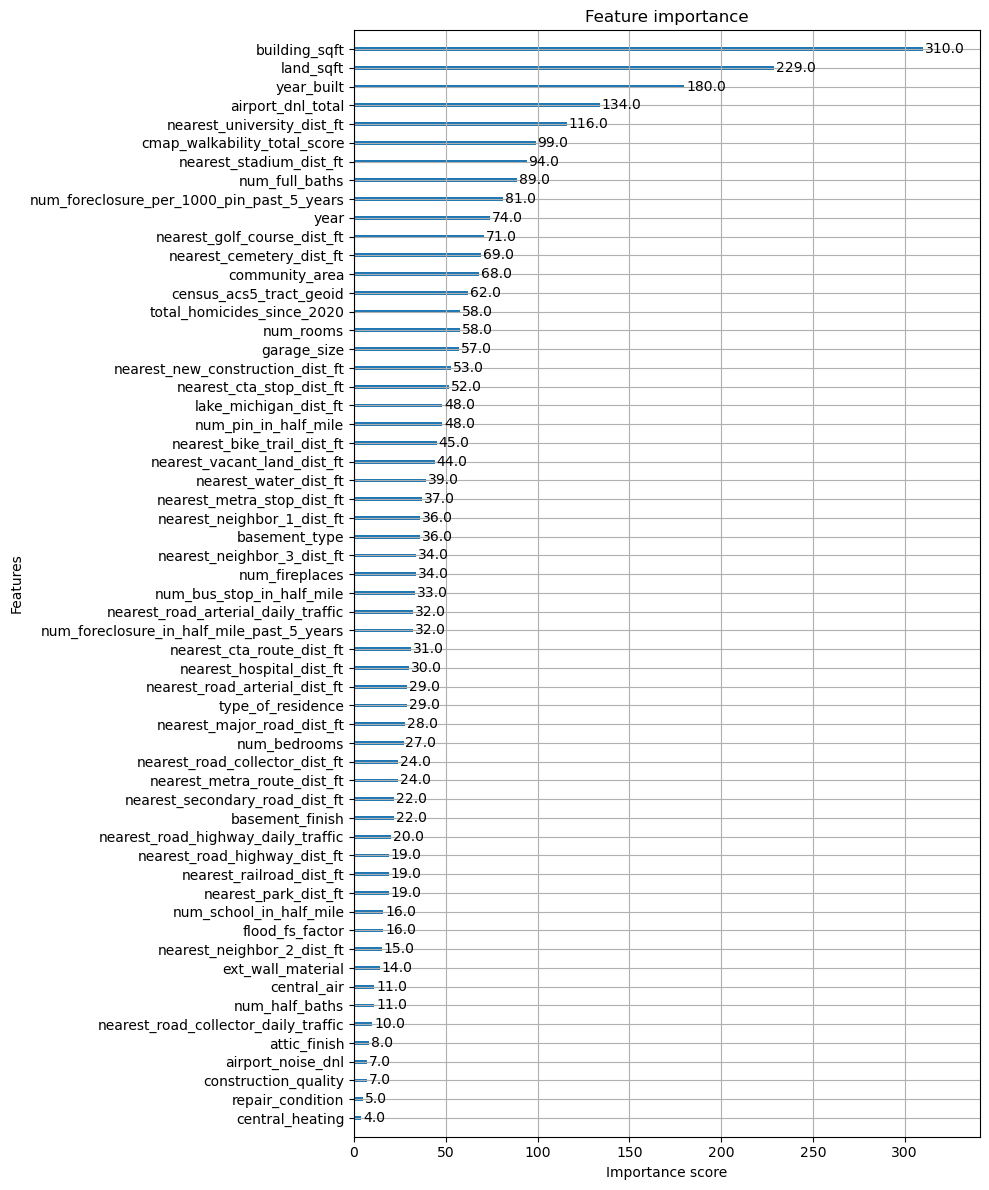

In [37]:
fig, ax = plt.subplots(figsize=(10, 12))  # wider and taller
xgb.plot_importance(model, ax=ax)
plt.tight_layout()
plt.show()

In [38]:
def categorical_pdp(model, X, feature, categories=None):
    """
    Compute partial dependence (marginal expected value) for a categorical feature.
    
    model: fitted XGBRegressor (enable_categorical=True)
    X: DataFrame used for prediction (same columns/dtypes as training)
    feature: name of the categorical column
    categories: optional list/order of categories to evaluate; defaults to all observed categories
    """
    if categories is None:
        categories = X[feature].cat.categories if hasattr(X[feature], "cat") else X[feature].unique()

    results = []
    X_temp = X.copy()

    for cat in categories:
        X_temp[feature] = cat
        # preserve categorical dtype/categories so xgboost doesn't complain
        X_temp[feature] = X_temp[feature].astype(X[feature].dtype)
        preds = model.predict(X_temp)
        results.append({"category": cat, "mean_prediction": preds.mean(), "std_prediction": preds.std()})

    return pd.DataFrame(results).sort_values("mean_prediction", ascending=False)

pdp_df = categorical_pdp(model, X, "community_area")
print(pdp_df)

    category  mean_prediction  std_prediction
29         5     526590.56250    403951.90625
62         4     526590.56250    403951.90625
51         2     526365.87500    403655.46875
52         3     526365.87500    403655.46875
17         1     526365.87500    403655.46875
..       ...              ...             ...
21        62     404422.21875    414924.53125
26        53     404422.21875    414924.53125
46        66     404422.21875    414924.53125
38        61     404422.21875    414924.53125
33        68     404212.93750    414986.25000

[76 rows x 3 columns]
